In [69]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
from scipy.interpolate import griddata

In [70]:
x = np.linspace(start=-1.5,stop=1.5,num=2000)
y = np.linspace(start=-1.5,stop=1.5,num=2000)

In [71]:
X, Y = np.meshgrid(x, y)

In [72]:
X.shape
Y.shape

(2000, 2000)

In [73]:
def func(x, y, a = 0.5, s = 0.25):
  return np.exp((-((x-a)**2+y**2)/(2*s**2)))+np.exp((-((x+a)**2+y**2)/(2*s**2)))

In [74]:
u = func(X, Y)


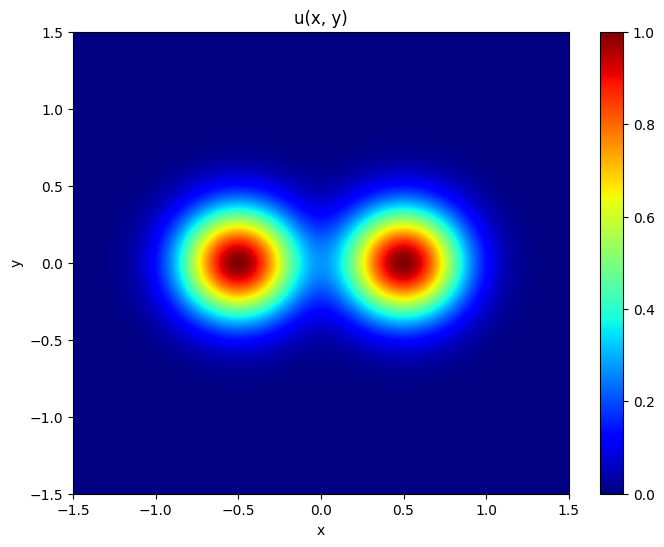

In [75]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, u, cmap='jet', shading='auto')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('u(x, y)')
plt.show()

In [76]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

a = 0.5
sigma = 0.25

n = 10000

x = np.random.uniform(-1, 1, n)
y = np.random.uniform(-1, 1, n)

u = (
    np.exp(-((x - a)**2 + y**2) / (2 * sigma**2))
    + np.exp(-((x + a)**2 + y**2) / (2 * sigma**2))
)

X = np.column_stack((x, y))
Y = u.reshape(-1, 1)

X = torch.tensor(X, dtype=torch.float32).to(device)
Y = torch.tensor(Y, dtype=torch.float32).to(device)

In [77]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [78]:
base_model = Net().to(device)
initial_state = base_model.state_dict()

model_adamw = Net().to(device)
model_adamw.load_state_dict(initial_state)

model_rmsprop = Net().to(device)
model_rmsprop.load_state_dict(initial_state)

model_sgd = Net().to(device)
model_sgd.load_state_dict(initial_state)

criterion = nn.MSELoss()

optimizer_adamw = torch.optim.AdamW(
    model_adamw.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

optimizer_rmsprop = torch.optim.RMSprop(
    model_rmsprop.parameters(),
    lr=0.001
)

optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

lambda_lr = lambda epoch: 0.999 ** epoch

scheduler_sgd = torch.optim.lr_scheduler.LambdaLR(
    optimizer_sgd,
    lr_lambda=lambda_lr
)

In [79]:
epochs = 2000

loss_adamw = []
loss_rmsprop = []
loss_sgd = []

lr_adamw = []
lr_rmsprop = []
lr_sgd = []

for epoch in range(epochs):

    optimizer_adamw.zero_grad()
    prediction = model_adamw(X)
    loss = criterion(prediction, Y)
    loss.backward()
    optimizer_adamw.step()

    loss_adamw.append(loss.item())
    lr_adamw.append(optimizer_adamw.param_groups[0]["lr"])

    optimizer_rmsprop.zero_grad()
    prediction = model_rmsprop(X)
    loss = criterion(prediction, Y)
    loss.backward()
    optimizer_rmsprop.step()

    loss_rmsprop.append(loss.item())
    lr_rmsprop.append(optimizer_rmsprop.param_groups[0]["lr"])

    optimizer_sgd.zero_grad()
    prediction = model_sgd(X)
    loss = criterion(prediction, Y)
    loss.backward()
    optimizer_sgd.step()
    scheduler_sgd.step()

    loss_sgd.append(loss.item())
    lr_sgd.append(optimizer_sgd.param_groups[0]["lr"])

AdamW final loss: 0.00016845636127982289
RMSprop final loss: 0.0007451793062500656
SGD final loss: 0.019226523116230965
AdamW final learning rate: 0.001
RMSprop final learning rate: 0.001
SGD final learning rate: 0.0013519992539749945


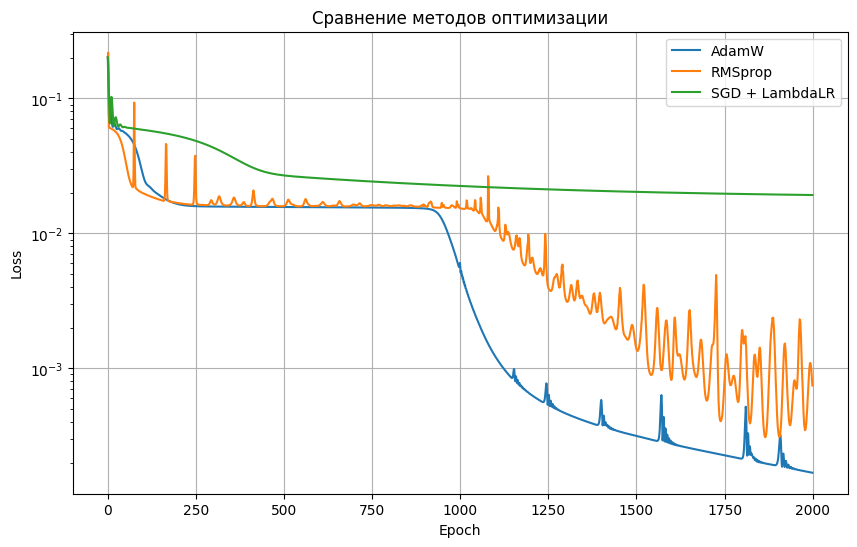

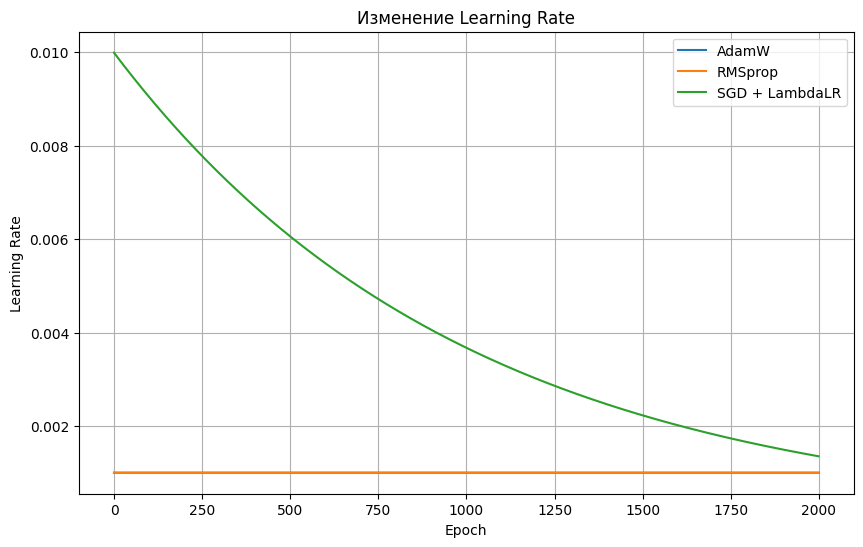

AdamW prediction MSE: 0.00018845372234820064
RMSprop prediction MSE: 0.0007083522174642728
SGD prediction MSE: 0.018991322088097957


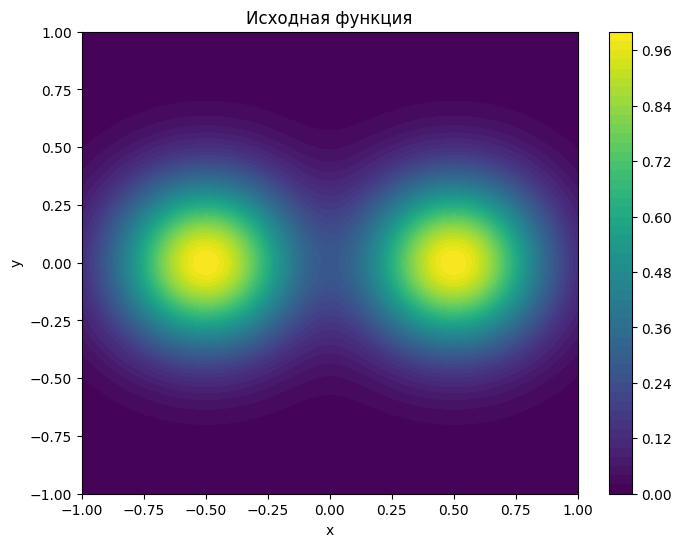

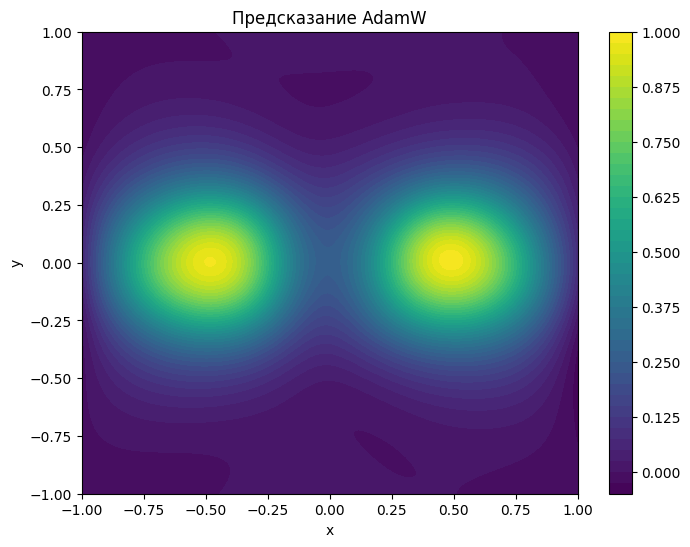

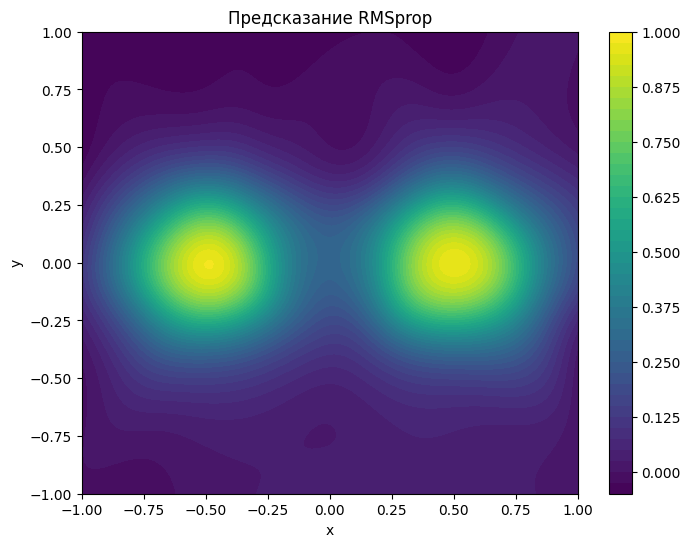

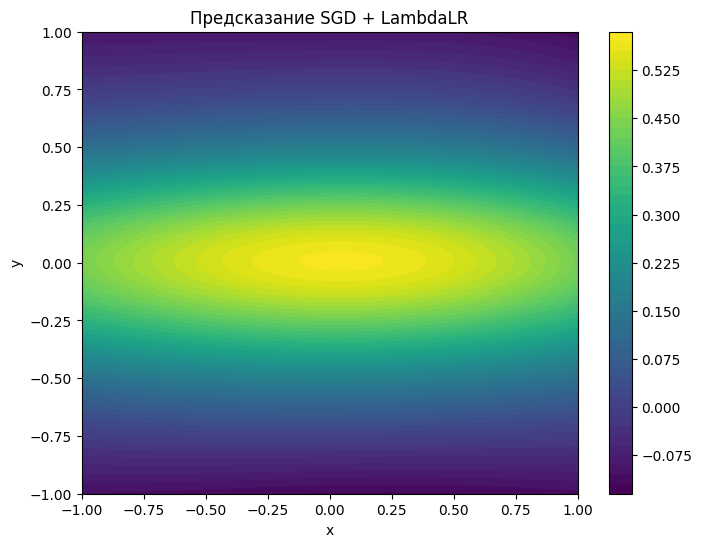

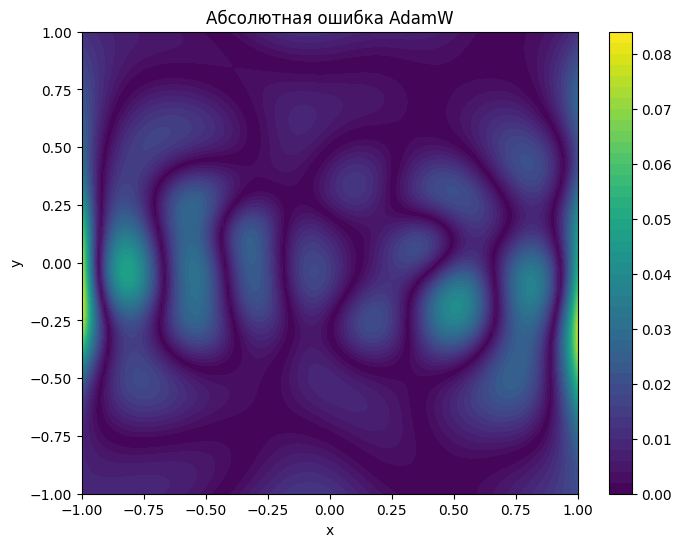

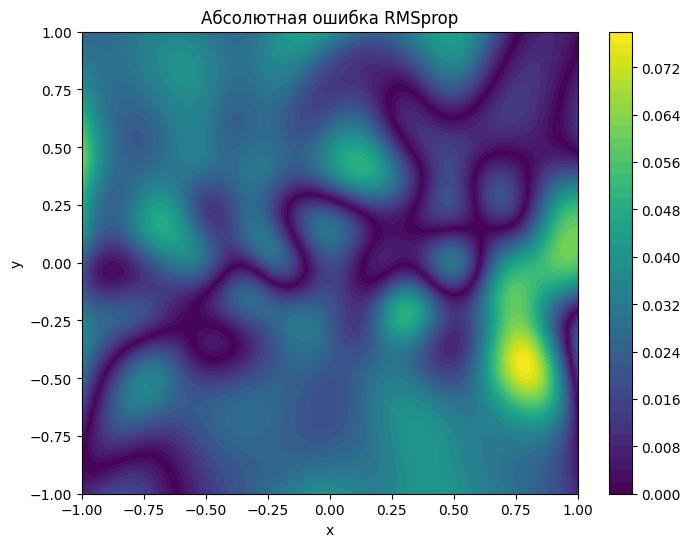

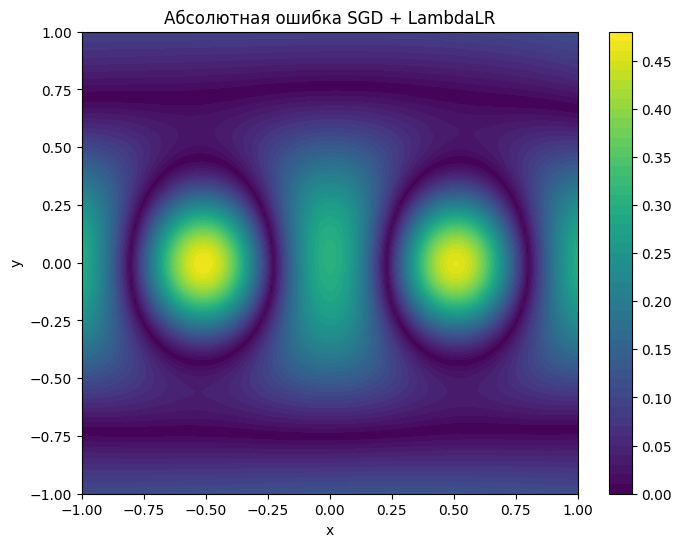

In [80]:
print("AdamW final loss:", loss_adamw[-1])
print("RMSprop final loss:", loss_rmsprop[-1])
print("SGD final loss:", loss_sgd[-1])

print("AdamW final learning rate:", lr_adamw[-1])
print("RMSprop final learning rate:", lr_rmsprop[-1])
print("SGD final learning rate:", lr_sgd[-1])


plt.figure(figsize=(10, 6))

plt.plot(loss_adamw, label="AdamW")
plt.plot(loss_rmsprop, label="RMSprop")
plt.plot(loss_sgd, label="SGD + LambdaLR")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Сравнение методов оптимизации")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(lr_adamw, label="AdamW")
plt.plot(lr_rmsprop, label="RMSprop")
plt.plot(lr_sgd, label="SGD + LambdaLR")

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Изменение Learning Rate")
plt.legend()
plt.grid()
plt.show()


model_adamw.eval()
model_rmsprop.eval()
model_sgd.eval()

grid = 150

x_plot = np.linspace(-1, 1, grid)
y_plot = np.linspace(-1, 1, grid)

X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

U_true = (
    np.exp(-((X_grid - a)**2 + Y_grid**2) / (2 * sigma**2))
    + np.exp(-((X_grid + a)**2 + Y_grid**2) / (2 * sigma**2))
)

XY_grid = np.column_stack((
    X_grid.ravel(),
    Y_grid.ravel()
))

XY_grid = torch.tensor(
    XY_grid,
    dtype=torch.float32
).to(device)

with torch.no_grad():
    U_pred_adamw = model_adamw(XY_grid).cpu().numpy().reshape(grid, grid)
    U_pred_rmsprop = model_rmsprop(XY_grid).cpu().numpy().reshape(grid, grid)
    U_pred_sgd = model_sgd(XY_grid).cpu().numpy().reshape(grid, grid)


error_adamw = np.abs(U_pred_adamw - U_true)
error_rmsprop = np.abs(U_pred_rmsprop - U_true)
error_sgd = np.abs(U_pred_sgd - U_true)

mse_adamw = np.mean((U_pred_adamw - U_true) ** 2)
mse_rmsprop = np.mean((U_pred_rmsprop - U_true) ** 2)
mse_sgd = np.mean((U_pred_sgd - U_true) ** 2)

print("AdamW prediction MSE:", mse_adamw)
print("RMSprop prediction MSE:", mse_rmsprop)
print("SGD prediction MSE:", mse_sgd)


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, U_true, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Исходная функция")
plt.show()


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, U_pred_adamw, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Предсказание AdamW")
plt.show()


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, U_pred_rmsprop, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Предсказание RMSprop")
plt.show()


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, U_pred_sgd, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Предсказание SGD + LambdaLR")
plt.show()


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, error_adamw, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Абсолютная ошибка AdamW")
plt.show()


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, error_rmsprop, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Абсолютная ошибка RMSprop")
plt.show()


plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, error_sgd, levels=50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Абсолютная ошибка SGD + LambdaLR")
plt.show()